In [1]:
#All necessary imports and dependecies
import matplotlib.pyplot as plt
import numpy as np
import PIL
from PIL import Image
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Conv2D, Flatten
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import SGD, Adam

from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2 
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from keras.layers import Dropout

In [3]:
import pathlib
data_dir = pathlib.Path("/Users/willjrice/Downloads/Tensorflow/testspace/sorted_amoebas2") #path to training data, classes sorted by folder
print(data_dir)

/Users/willamrice/Downloads/Tensorflow/testspace/sorted_amoebas2


In [5]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count) #to get a sense of the size of training data

1999


In [9]:
#Class Names
class_names = ['eaten', 'not_eaten']

In [11]:
batch_size = 32 #Bigger takes less time, but eats up more memory
img_height = 299
img_width = 299

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory( #create the training dataset
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1999 files belonging to 2 classes.
Using 1600 files for training.


2026-04-24 14:27:39.486670: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-24 14:27:39.486759: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-24 14:27:39.486777: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-24 14:27:39.486975: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 14:27:39.487292: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [15]:
val_ds = tf.keras.utils.image_dataset_from_directory( #create the testing dataset
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 1999 files belonging to 2 classes.
Using 399 files for validation.


In [17]:
AUTOTUNE = tf.data.AUTOTUNE #enables runtime to dynamically tune the number of prefetched elements during training, based on local memory/performance

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE) #apply AUTOTUNE to training data
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE) #apply AUTOTUNE to validation data

In [19]:
normalization_layer = layers.Rescaling(1./255) #rescales RGB channel values from [0,255] to [0,1]

In [21]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)) #applies normalization to training data
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[2]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))
print(first_image)

0.00019774638 1.0
tf.Tensor(
[[[0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  ...
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]]

 [[0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  ...
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]]

 [[0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  [0.68235296 0.69803923 0.9490197 ]
  ...
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]
  [0.6627451  0.6784314  0.9568628 ]]

 ...

 [[0.1764706  0.18039216 0.5058824 ]
  [0.1764706  0.18039216 0.5058824 ]
  [0.1764706  0.18039216 0.5058824 ]
  ...
  [0.5568628  0.5568628  0.90196085]
  [0.5568628  0.5568628  0.90196085]
  [0.5568628  0.5568628  0.90196085]]

 [[0.1764706  0.18039216 0.5058824 ]
  [0.176

In [93]:
num_classes = len(class_names)

#EfficientNetB1
ptm = keras.applications.EfficientNetB1(
    include_top=False, #Whether to include the fully-connected layer at the top of the network; False best for transfer learning
    weights="imagenet", #Whether to use pre-trained weights
    input_tensor=None, #Optional keras tensor
    input_shape=(img_height, img_width, 3), #Input shape of data; height, width, and 3 for RBG channels
    pooling=None, #Optional layer to reduce spatial dimensions of output; None defaults to full 4D Tensor
    classifier_activation="softmax", #scales outputs into a list of probabilities adding to 1
)

data_augmentation = keras.Sequential([ #augments image data to prevent overfitting, increase training diversity
    layers.RandomFlip("horizontal"), #randomly flips images
    layers.RandomRotation(-0.5, 0.5), #randomly rotates image between 50% counterclockwise and 50% clockwise

    # Important for low-quality images
    layers.RandomContrast(0.2), #randomly adjusts contrast +/- 0.2
    layers.RandomBrightness(0.2), #randomly adjusts brightest +/- 0.2
    layers.GaussianNoise(0.05), #corrupts data slightly via random Guassian noise, 0.05 = stddev
])

inputs = keras.Input(shape=(img_height, img_width, 3)) #instaniate a Keras tensor
x = data_augmentation(inputs) #apply data_augmentation to inputs

ptm.trainable = False #only the newly added custom layers are trained and updated

x = layers.GlobalAveragePooling2D(name="avg_pool")(ptm.output) #condenses a 4D tensor into a 2D tensor
x = layers.BatchNormalization()(x) #normalizes inputs

x = Dense(256, activation = 'relu')(x) #Layer of 256 nuerons, relu introduces non-linearity for complex patterns
x = Dropout(0.4)(x) #randomly deactivates 40% of nuerons to prevent overfitting
x = Dense(128, activation = 'relu')(x) #Layer of 128 nuerons, relu introduces non-linearity for complex patterns
x = Dropout(0.3)(x) #randomly deactivates 30% of nuerons to prevent overfitting
outputs = layers.Dense(num_classes, activation = 'softmax')(x) #reduces to num_classes nuerons, assigns probabilties to each adding to 1
model = Model(inputs = ptm.input, outputs = outputs) #puts the model together


model.compile(loss = "sparse_categorical_crossentropy", #loss function
              optimizer = 'adam', #algorithm to update weight/biases of CNN to minimize loss function
              metrics = ['accuracy']) #what metrics to return

In [95]:
epochs=10
early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True) #stop the model automatically to prevent overfitting

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stop]
)

Epoch 1/10


2026-04-04 21:23:04.396851: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


50/50 [==============================] - 51s 845ms/step - loss: 1.2956 - accuracy: 0.7050 - val_loss: 0.4906 - val_accuracy: 0.7619
Epoch 2/10
50/50 [==============================] - 35s 702ms/step - loss: 0.9505 - accuracy: 0.7500 - val_loss: 0.4670 - val_accuracy: 0.7694
Epoch 3/10
50/50 [==============================] - 32s 633ms/step - loss: 0.9530 - accuracy: 0.7481 - val_loss: 0.4523 - val_accuracy: 0.8120
Epoch 4/10
50/50 [==============================] - 53s 1s/step - loss: 0.7688 - accuracy: 0.7769 - val_loss: 0.4134 - val_accuracy: 0.8045
Epoch 5/10
50/50 [==============================] - 36s 725ms/step - loss: 0.6519 - accuracy: 0.7906 - val_loss: 0.4504 - val_accuracy: 0.7895
Epoch 6/10
50/50 [==============================] - 36s 730ms/step - loss: 0.6868 - accuracy: 0.7900 - val_loss: 0.4326 - val_accuracy: 0.8095
Epoch 7/10
50/50 [==============================] - 36s 716ms/step - loss: 0.6005 - accuracy: 0.8037 - val_loss: 0.4333 - val_accuracy: 0.8045
Epoch 8/10
50

In [31]:
model.save('Armaan_EffNetB1_299x299.keras') #save the model in the current directory

In [23]:
model = keras.models.load_model('/Users/willamrice/Downloads/Tensorflow/testspace/Armaan_EffNetB1_299x299.keras') #load a model for interference

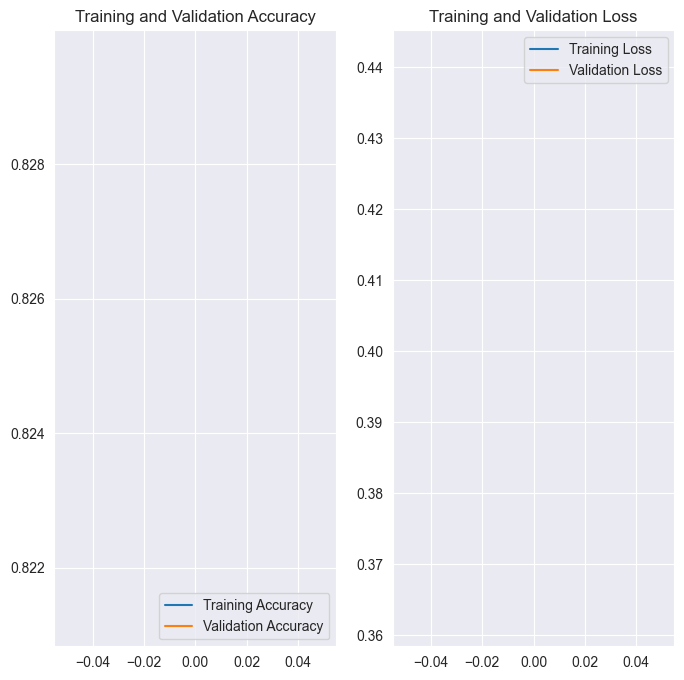

In [65]:
#get train accuracy in history
acc = history.history['accuracy']
#get validation accuracy
val_acc = history.history['val_accuracy']
# get train loss 
loss = history.history['loss']
#get validation loss
val_loss = history.history['val_loss']
if early_stop.stopped_epoch > 0:
    epochs_range = range(early_stop.stopped_epoch+1)
else:
    epochs_range = range(epochs)
    
# plot accuracy
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
# plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

2026-04-24 14:28:07.887935: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 8s 409ms/step
there were 352 correct predictions in 399 tests for an accuracy of  88.22 % 


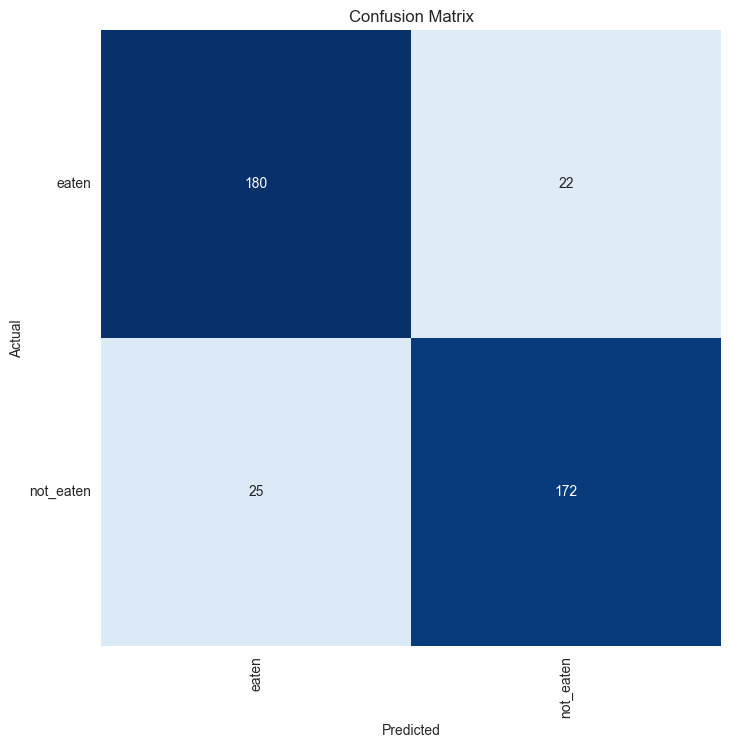

Classification Report:
----------------------
               precision    recall  f1-score   support

       eaten       0.88      0.89      0.88       202
   not_eaten       0.89      0.87      0.88       197

    accuracy                           0.88       399
   macro avg       0.88      0.88      0.88       399
weighted avg       0.88      0.88      0.88       399



In [25]:
#CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
sns.set_style('darkgrid')
classes= class_names # ordered list of class names
ytrue=[] #empty list for true labels
for images, label in val_ds: #go through each image and its true label in val_ds
    for e in label: #get the true label
        ytrue.append(classes[e]) # build ordered list of true labels 
ypred=[] #list of predicted labels
errors=0
count=0
preds=model.predict(val_ds, verbose=1) # predict on the test data, verbose=1 means show animated progress
for i, p in enumerate(preds):
    count +=1
    index=np.argmax(p) # get index of prediction with highest probability
    klass=classes[index] 
    ypred.append(klass)  
    if klass != ytrue[i]:
        errors +=1
acc= (count-errors)* 100/count
msg=f'there were {count-errors} correct predictions in {count} tests for an accuracy of {acc:6.2f} % '
print(msg) 
ypred=np.array(ypred)
ytrue=np.array(ytrue)
if len(classes)<= 30: # if more than 30 classes plot is not useful to cramed
    # create a confusion matrix 
    cm = confusion_matrix(ytrue, ypred)        
    length=len(classes)
    if length<8:
        fig_width=8
        fig_height=8
    else:
        fig_width= int(length * .5)
        fig_height= int(length * .5)
    plt.figure(figsize=(fig_width, fig_height))
    sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)       
    plt.xticks(np.arange(length)+.5, classes, rotation= 90)
    plt.yticks(np.arange(length)+.5, classes, rotation=0)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()
clr = classification_report(ytrue, ypred, target_names=class_names)
print("Classification Report:\n----------------------\n", clr) 

In [68]:
# Code to show which images in validation are correctly and incorrectly sorted

# Converts val_ds back into images and sort them into layered directories, where the first layer is the predicted values 
# and the second layer is the actual value. e.g /path/to/dest/class_1/class_1/image.png is a correctly-sorted image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import shutil



dest = "/Users/willamrice/Downloads/Tensorflow/testspace/sorted_amoebas/" #Where to output results of sorting

dict = {0 : 'eaten',
        1 : 'not_eaten'
       } 
j = 0
preds=model.predict(val_ds, verbose=1) #predictions on validation dataset
for image_batch, label_batch in val_ds:
    # Preprocess image
    for i in range(image_batch.shape[0]):
        predicted_class_index = np.argmax(preds[j]) #get class with highest probability
        predicted_class_name = class_names[predicted_class_index] #get class_name of prediction from index
        actual_class_name = dict[label_batch[i].numpy()] #actual manual classification
        print(f"Predicted {predicted_class_name}, actually {actual_class_name}")
        
        # Create destination folder if it doesn't exist
        reg_img = image_batch[i]
        reg_img = reg_img.numpy()
        pil_image = Image.fromarray(reg_img.astype('uint8')) #Convert to image for computer to save
        destination_folder = os.path.join(dest, predicted_class_name, actual_class_name) #save to dest/predicted/actual
        os.makedirs(destination_folder, exist_ok=True) #make directory to destination if not already exist
        image_filename = os.path.join(destination_folder,  f'{j}.png') #full path including the amoeba image
        pil_image.save(image_filename)
        j += 1

13/13 [==============================] - 7s 498ms/step
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually eaten
Predicted eaten, actually eaten
Predicted eaten, actually eaten
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually eaten
Predicted not_eaten, actually not_eaten
Predicted eaten, actually eaten
Predicted eaten, actually not_eaten
Predicted eaten, actually eaten
Predicted eaten, actually eaten
Predicted eaten, actually eaten
Predicted eaten, actually not_eaten
Predicted eaten, actually eaten
Predicted eaten, actually not_eaten
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually not_eaten
Predicted eaten, actually not_eaten
Predicted eaten, actually eaten
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually not_eaten
Predicted not_eaten, actually not_eaten
Predicted eaten, actually eaten
Predicted eaten, actually eaten
Predicted eaten, actually not_eaten
Predicted eat

In [21]:
#Code for running a full-scale image classification program

import csv
import os
dirs = ['AR1', 'BR3', 'CR2', 'DR3'] #Name of each directory representing a well 
cur = '/Users/wjrice/Desktop/1000_GENOME_Amoebas/' #Main directory of all the wells
for new_dir in dirs:
    data = []
    curcur = cur + new_dir #Directory to a specific well
    for root, dirs2, files in os.walk(curcur):
        if files == ['.DS_Store'] or files == []: #if not in a subfolder
            continue
        test_images = [] #list of all paths to individual images
        for img in files:
            if img.endswith('jpg'):
                test_images.append(os.path.join(root, img))
        name = os.path.basename(root) #Name of the particular well
        eaten = 0
        not_eaten = 0
        for image_path in test_images: #get predictions on everything
            head, tail = os.path.split(image_path)
            
            img = image.load_img(image_path, target_size=(299, 299)) # Adjust target_size for your model
            img_array = image.img_to_array(img) #convert img to array
            img_array = np.expand_dims(img_array, axis=0) #Expands dimensions by adding a 1 into 1st position of array
        
            # Make prediction
            predictions = model.predict(img_array, verbose=0) #run classification on image
            predicted_class_index = tf.argmax(predictions[0]).numpy() #get class index with highest probability
        
            # Assuming you have a list of class names corresponding to your model's output
            predicted_class_name = class_names[predicted_class_index] #get predicted class_name from index 
            if predicted_class_name == 'eaten':
                eaten +=1 #augment by 1 if predicted to be eaten
            if predicted_class_name == 'not_eaten':
                not_eaten +=1 #augment by 1 if predicted to be noneaten
        try:
            data.append({'Well' : name, #Well name
                         'eaten' : eaten, #number of eaten
                         'uneaten' : not_eaten, #number of uneaten
                         'ratio' : eaten/(eaten+not_eaten)}) #ratio of eaten to total amoebas ("predation rate")
            print({'Well' : name, 
                         'eaten' : eaten, 
                         'uneaten' : not_eaten,
                         'ratio' : eaten/(eaten+not_eaten)})
        except ZeroDivisionError: #in case something like this occurs, error in ratio
            data.append({'Well' : name, 
                         'eaten' : eaten, 
                         'uneaten' : not_eaten,
                         'ratio' : 'N/A'})
            print({'Well' : name, 
                         'eaten' : eaten, 
                         'uneaten' : not_eaten,
                          'ratio' : 'N/A'})
    with open('Amoebas.csv', 'a', newline='') as csvfile:
        fieldnames = ['Well', 'eaten', 'uneaten', 'ratio'] #each statistic
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writerows(data)
    print("All Done!")
print("All completed")

{'Well': 'AR1_F6.3', 'eaten': 4, 'uneaten': 6, 'ratio': 0.4}
{'Well': 'AR1_D7.2', 'eaten': 14, 'uneaten': 10, 'ratio': 0.5833333333333334}
{'Well': 'AR1_B4.1', 'eaten': 12, 'uneaten': 3, 'ratio': 0.8}
{'Well': 'AR1_H1.3', 'eaten': 1, 'uneaten': 2, 'ratio': 0.3333333333333333}
{'Well': 'AR1_G12.2', 'eaten': 2, 'uneaten': 4, 'ratio': 0.3333333333333333}
{'Well': 'AR1_D12.3', 'eaten': 2, 'uneaten': 6, 'ratio': 0.25}
{'Well': 'AR1_B6.2', 'eaten': 12, 'uneaten': 13, 'ratio': 0.48}
{'Well': 'AR1_D5.1', 'eaten': 7, 'uneaten': 1, 'ratio': 0.875}
{'Well': 'AR1_G10.1', 'eaten': 3, 'uneaten': 6, 'ratio': 0.3333333333333333}
{'Well': 'AR1_F10.1', 'eaten': 5, 'uneaten': 3, 'ratio': 0.625}
{'Well': 'AR1_H5.2', 'eaten': 3, 'uneaten': 9, 'ratio': 0.25}
{'Well': 'AR1_D3.3', 'eaten': 5, 'uneaten': 8, 'ratio': 0.38461538461538464}
{'Well': 'AR1_E12.3', 'eaten': 4, 'uneaten': 2, 'ratio': 0.6666666666666666}
{'Well': 'AR1_F2.2', 'eaten': 4, 'uneaten': 11, 'ratio': 0.26666666666666666}
{'Well': 'AR1_B8.3', 

In [ ]:
# Code for sorting a specific collection of images
# Will sort images into folders, with the terminal folders representing classification predictions
from tensorflow import keras
from tensorflow.keras.preprocessing import image
import numpy as np
import os
import shutil

image_folder_path = '/Users/willamrice/Downloads/Tensorflow/testspace/to_sort' #path to all images
class_names = {0 : 'eaten',
               1 : 'not_eaten',
              }

for filename in os.listdir(image_folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif')): #if an image
        img_path = os.path.join(image_folder_path, filename) #full path to image

        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(299, 299)) # Adjust target_size for your model
        img_array = image.img_to_array(img) #convert img to array
        img_array = np.expand_dims(img_array, axis=0) #Expands dimensions by adding a 1 into 1st position of array

        # Make a prediction
        predictions = model.predict(img_array) #run classification on image
        predicted_class_index = tf.argmax(predictions[0]).numpy() #get class index with highest probability
        predicted_class_name = class_names[predicted_class_index] #get predicted class_name from index

        # Create destination folder if it doesn't exist
        destination_folder = os.path.join(image_folder_path, predicted_class_name) #make directory to prediction
        os.makedirs(destination_folder, exist_ok=True) #make directory if doesn't already exist

        # Move the image to the classified folder
        shutil.move(img_path, os.path.join(destination_folder, filename)) #Move the image into the predicted folder
        print(f"Moved '{filename}' to '{predicted_class_name}' folder.")